--- Avaliando Bag of Words ---
Bag of Words (RF) - Acurácia: 95.745%, F1-score: 0.941
Bag of Words (KMeans) - Silhouette Score: 0.132
---

--- Avaliando TF-IDF + PCA ---
TF-IDF + PCA (RF) - Acurácia: 100.000%, F1-score: 1.000
TF-IDF + PCA (KMeans) - Silhouette Score: 0.098
---

--- Avaliando Word2Vec ---
Baixando modelo Word2Vec 'glove-wiki-gigaword-100'...
[==================================================] 100.0% 128.1/128.1MB downloaded
Word2Vec (RF) - Acurácia: 95.745%, F1-score: 0.941
Word2Vec (KMeans) - Silhouette Score: 0.295
---

--- Avaliando BERT ---


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

BERT (RF) - Acurácia: 85.106%, F1-score: 0.759
BERT (KMeans) - Silhouette Score: 0.209
---

--- Tabela Comparativa de Classificação (Random Forest) ---
                      Acurácia (%)  F1-score
Técnica de Embedding                        
Bag of Words             95.744681  0.941176
TF-IDF + PCA            100.000000  1.000000
Word2Vec                 95.744681  0.941176
BERT                     85.106383  0.758621

--- Tabela Comparativa de Clusterização (K-means) ---
                      Silhouette Score
Técnica de Embedding                  
Bag of Words                  0.132064
TF-IDF + PCA                  0.098082
Word2Vec                      0.294844
BERT                          0.209483


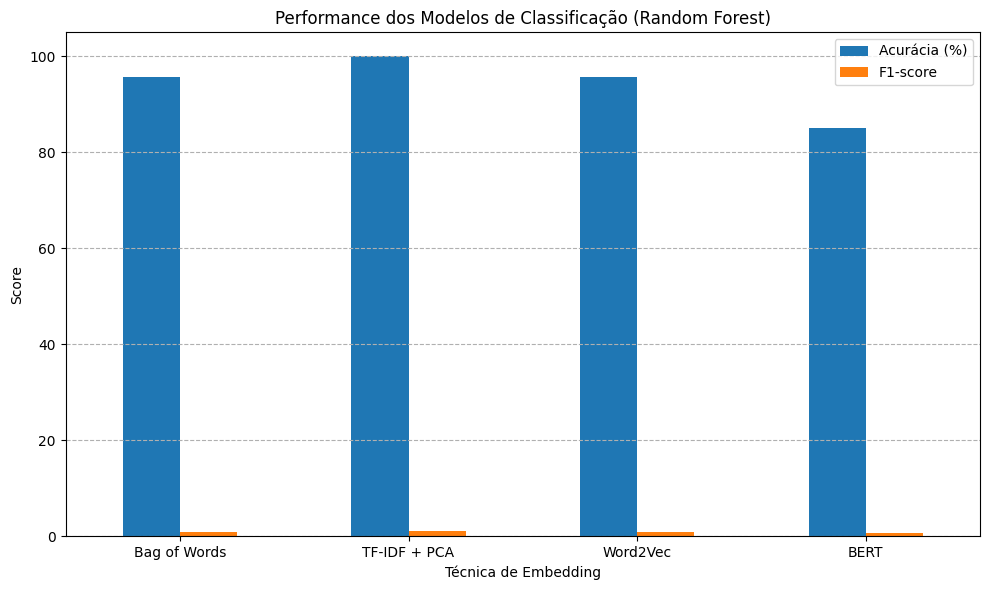

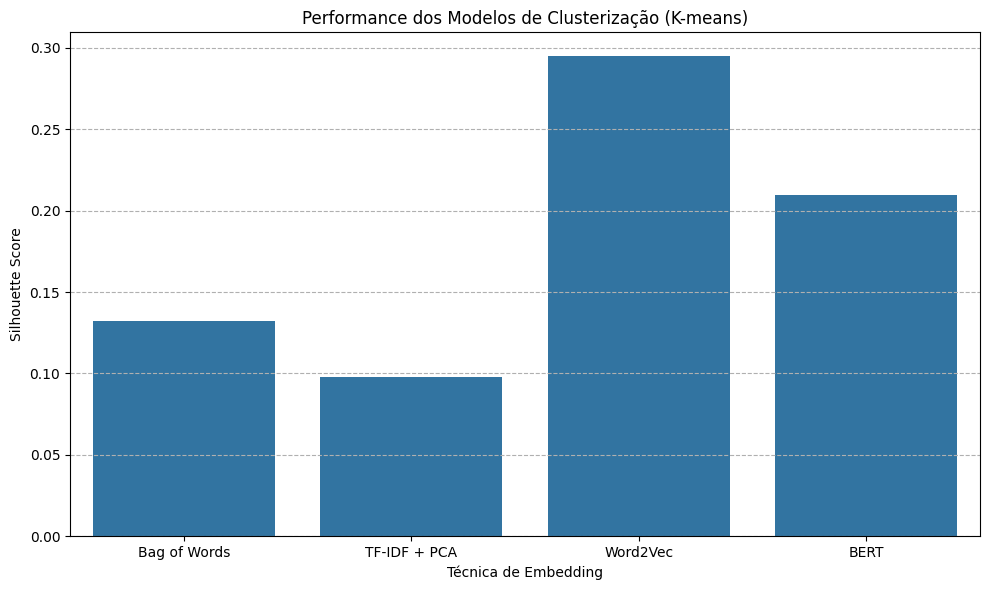

In [1]:
# Instalação das bibliotecas necessárias
#!pip install gensim
#!pip install transformers
#!pip install matplotlib seaborn

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, silhouette_score
import gensim.downloader
import torch
from transformers import BertTokenizer, BertModel

# Carregar o dataset CVE do NVD
with open('nvdcve-1.1-recent.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

# --- Extração e Pré-processamento dos Dados ---
cve_items = data['CVE_Items']
records = []
for item in cve_items:
    cve_id = item['cve']['CVE_data_meta']['ID']
    description = item['cve']['description']['description_data'][0]['value']
    cvss_score = item['impact'].get('baseMetricV3', {}).get('cvssV3', {}).get('baseScore', 0)
    records.append({'id': cve_id, 'description': description, 'cvss': cvss_score})

df = pd.DataFrame(records)
df = df[df['cvss'] > 0]
df['label'] = df['cvss'].apply(lambda x: 1 if x >= 7 else 0)
descriptions = df['description'].tolist()
y = df['label']

# Dicionários para armazenar os resultados
rf_results = {}
kmeans_results = {}

# 1 Bag of Words
print("--- Avaliando Bag of Words ---")
vectorizer_bow = CountVectorizer(stop_words='english', max_features=1000)
X_text_bow = vectorizer_bow.fit_transform(descriptions).toarray()
X_bow_final = np.hstack((X_text_bow, df[['cvss']].values))

X_train_bow, X_test_bow, y_train_bow, y_test_bow = train_test_split(X_bow_final, y, test_size=0.2, random_state=42)
rf_bow = RandomForestClassifier(n_estimators=100, random_state=42)
rf_bow.fit(X_train_bow, y_train_bow)
y_pred_bow = rf_bow.predict(X_test_bow)
rf_results['Bag of Words'] = {
    'Acuracia': accuracy_score(y_test_bow, y_pred_bow) * 100,
    'F1-score': f1_score(y_test_bow, y_pred_bow)
}

kmeans_bow = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_bow.fit(X_text_bow)
kmeans_results['Bag of Words'] = silhouette_score(X_text_bow, kmeans_bow.labels_)
print(f"Bag of Words (RF) - Acurácia: {rf_results['Bag of Words']['Acuracia']:.3f}%, F1-score: {rf_results['Bag of Words']['F1-score']:.3f}")
print(f"Bag of Words (KMeans) - Silhouette Score: {kmeans_results['Bag of Words']:.3f}")
print("---")

# 2 TF-IDF + PCA
print("\n--- Avaliando TF-IDF + PCA ---")
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
X_tfidf = tfidf_vectorizer.fit_transform(descriptions)
pca = PCA(n_components=100, random_state=42)
X_tfidf_pca = pca.fit_transform(X_tfidf.toarray())
X_tfidf_final = np.hstack((X_tfidf_pca, df[['cvss']].values))

X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(X_tfidf_final, y, test_size=0.2, random_state=42)
rf_tfidf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_tfidf.fit(X_train_tfidf, y_train_tfidf)
y_pred_tfidf = rf_tfidf.predict(X_test_tfidf)
rf_results['TF-IDF + PCA'] = {
    'Acuracia': accuracy_score(y_test_tfidf, y_pred_tfidf) * 100,
    'F1-score': f1_score(y_test_tfidf, y_pred_tfidf)
}

kmeans_tfidf = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_tfidf.fit(X_tfidf_pca)
kmeans_results['TF-IDF + PCA'] = silhouette_score(X_tfidf_pca, kmeans_tfidf.labels_)
print(f"TF-IDF + PCA (RF) - Acurácia: {rf_results['TF-IDF + PCA']['Acuracia']:.3f}%, F1-score: {rf_results['TF-IDF + PCA']['F1-score']:.3f}")
print(f"TF-IDF + PCA (KMeans) - Silhouette Score: {kmeans_results['TF-IDF + PCA']:.3f}")
print("---")

# 3 Word2Vec
print("\n--- Avaliando Word2Vec ---")
tokenized_descriptions = [desc.split() for desc in descriptions]
print("Baixando modelo Word2Vec 'glove-wiki-gigaword-100'...")
model_w2v = gensim.downloader.load('glove-wiki-gigaword-100')

def get_doc_vector(doc, model):
    vectors = [model[word] for word in doc if word in model.key_to_index]
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)

X_w2v = np.array([get_doc_vector(desc, model_w2v) for desc in tokenized_descriptions])
zero_rows = ~np.all(X_w2v == 0, axis=1)
X_w2v = X_w2v[zero_rows]
y_w2v = y[zero_rows]
cvss_w2v = df[zero_rows][['cvss']].values
X_w2v_final = np.hstack((X_w2v, cvss_w2v))

X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = train_test_split(X_w2v_final, y_w2v, test_size=0.2, random_state=42)
rf_w2v = RandomForestClassifier(n_estimators=100, random_state=42)
rf_w2v.fit(X_train_w2v, y_train_w2v)
y_pred_w2v = rf_w2v.predict(X_test_w2v)
rf_results['Word2Vec'] = {
    'Acuracia': accuracy_score(y_test_w2v, y_pred_w2v) * 100,
    'F1-score': f1_score(y_test_w2v, y_pred_w2v)
}

kmeans_w2v = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_w2v.fit(X_w2v)
kmeans_results['Word2Vec'] = silhouette_score(X_w2v, kmeans_w2v.labels_)
print(f"Word2Vec (RF) - Acurácia: {rf_results['Word2Vec']['Acuracia']:.3f}%, F1-score: {rf_results['Word2Vec']['F1-score']:.3f}")
print(f"Word2Vec (KMeans) - Silhouette Score: {kmeans_results['Word2Vec']:.3f}")
print("---")

# 4 BERT Embeddings
print("\n--- Avaliando BERT ---")
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model_bert = BertModel.from_pretrained('bert-base-uncased')

def get_bert_embeddings(text, tokenizer, model):
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state[:, 0, :].numpy().flatten()

X_bert_list = [get_bert_embeddings(desc, tokenizer, model_bert) for desc in descriptions]
X_bert = np.array(X_bert_list)
X_bert_final = np.hstack((X_bert, df[['cvss']].values))

X_train_bert, X_test_bert, y_train_bert, y_test_bert = train_test_split(X_bert_final, y, test_size=0.2, random_state=42)
rf_bert = RandomForestClassifier(n_estimators=100, random_state=42)
rf_bert.fit(X_train_bert, y_train_bert)
y_pred_bert = rf_bert.predict(X_test_bert)
rf_results['BERT'] = {
    'Acuracia': accuracy_score(y_test_bert, y_pred_bert) * 100,
    'F1-score': f1_score(y_test_bert, y_pred_bert)
}

kmeans_bert = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_bert.fit(X_bert)
silhouette_bert = silhouette_score(X_bert, kmeans_bert.labels_)
kmeans_results['BERT'] = silhouette_bert
print(f"BERT (RF) - Acurácia: {rf_results['BERT']['Acuracia']:.3f}%, F1-score: {rf_results['BERT']['F1-score']:.3f}")
print(f"BERT (KMeans) - Silhouette Score: {kmeans_results['BERT']:.3f}")
print("---")

# Tabela Comparativa
print("\n--- Tabela Comparativa de Classificação (Random Forest) ---")
df_rf_results = pd.DataFrame(rf_results).T
df_rf_results.index.name = 'Técnica de Embedding'
df_rf_results.columns = ['Acurácia (%)', 'F1-score']
print(df_rf_results)

# Tabela Comparativa
print("\n--- Tabela Comparativa de Clusterização (K-means) ---")
df_kmeans_results = pd.DataFrame(kmeans_results.items(), columns=['Técnica de Embedding', 'Silhouette Score'])
print(df_kmeans_results.set_index('Técnica de Embedding'))

# Gráfico de Acurácia e F1-score para Classificação
fig, ax1 = plt.subplots(figsize=(10, 6))
df_rf_results.plot(kind='bar', ax=ax1, rot=0)
ax1.set_title('Performance dos Modelos de Classificação (Random Forest)')
ax1.set_ylabel('Score')
ax1.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

# Gráfico de Silhouette Score para Clusterização
plt.figure(figsize=(10, 6))
sns.barplot(x=df_kmeans_results['Técnica de Embedding'], y=df_kmeans_results['Silhouette Score'])
plt.title('Performance dos Modelos de Clusterização (K-means)')
plt.ylabel('Silhouette Score')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()